# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
#Type your code here# Import library dasar untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library dari Scikit-Learn untuk tahap preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Menonaktifkan peringatan (warnings) agar notebook terlihat rapi dan bersih
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
#Type your code here# Membaca dataset CSV yang sudah diunggah ke Colab
df = pd.read_csv('heart.csv')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat dengan benar
print("Tampilan 5 baris pertama dataset:")
display(df.head())

# Menampilkan ringkasan informasi dataset (jumlah kolom, tipe data, dll)
print("\nRingkasan Informasi Dataset:")
df.info()

Tampilan 5 baris pertama dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Ringkasan Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

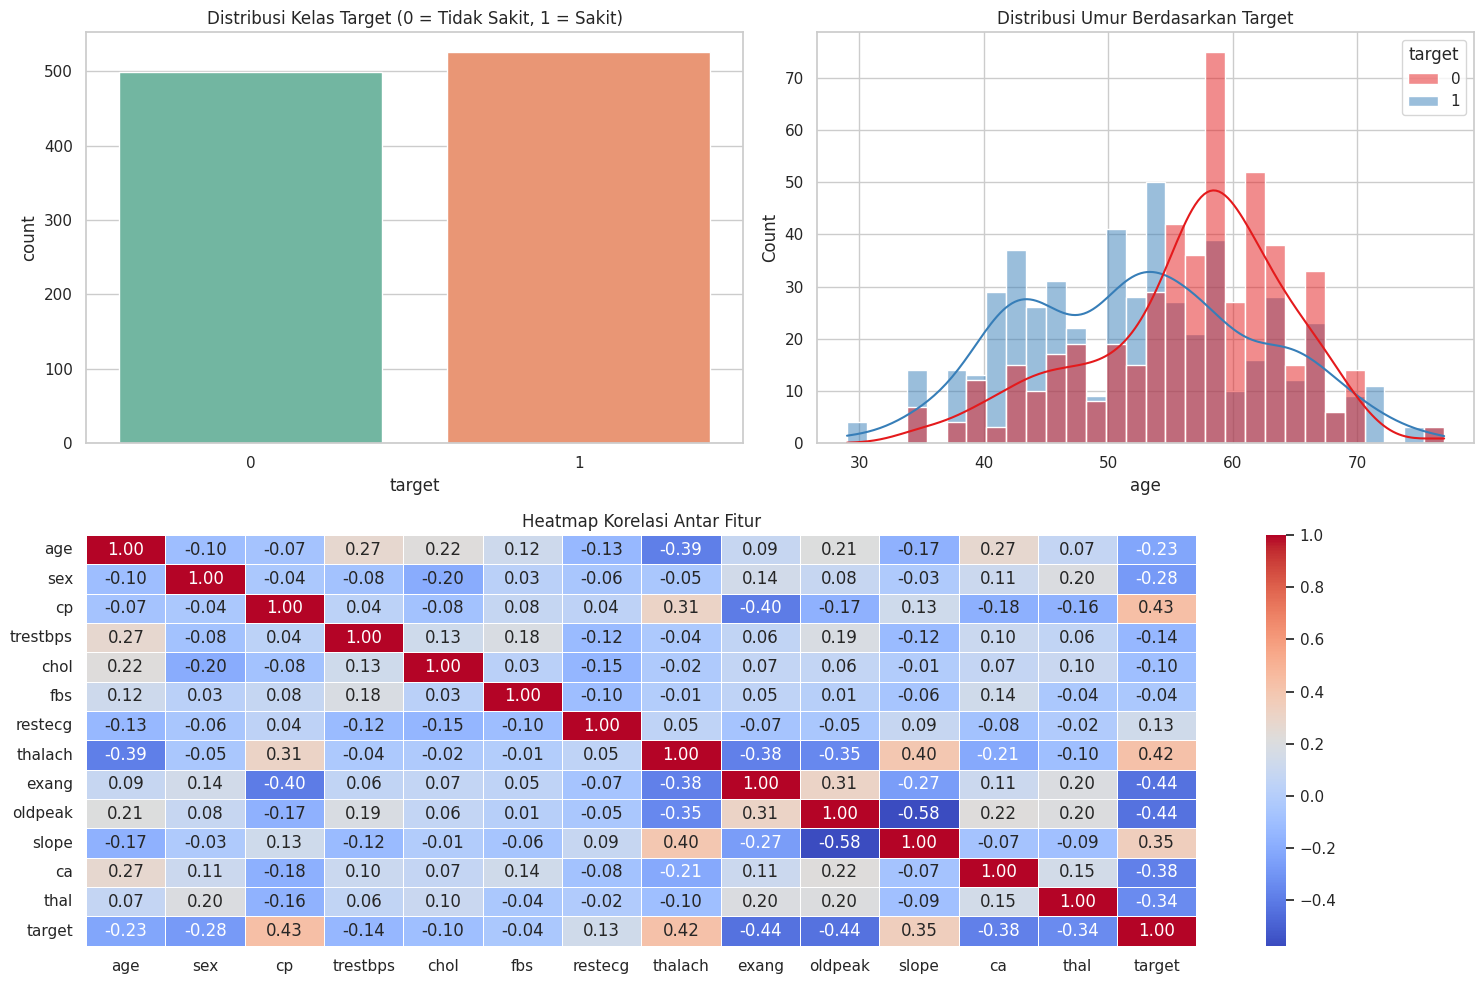

In [ ]:
#Type your code herimport matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya plot
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# 1. Visualisasi Distribusi Target (Apakah data seimbang?)
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribusi Kelas Target (0 = Tidak Sakit, 1 = Sakit)')

# 2. Visualisasi Hubungan Umur dengan Penyakit Jantung
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='age', hue='target', kde=True, palette='Set1', bins=30)
plt.title('Distribusi Umur Berdasarkan Target')

# 3. Heatmap Korelasi antar Fitur
plt.subplot(2, 2, (3, 4)) # Mengambil ruang lebih besar
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Mengecek nilai kosong (Missing Values) dan Duplikat
print("Jumlah Missing Values per kolom:\n", df.isnull().sum())

# Menghapus data duplikat jika ada
duplicate_count = df.duplicated().sum()
print(f"\nJumlah baris duplikat ditemukan: {duplicate_count}")
df = df.drop_duplicates()
print("Data duplikat telah dihapus.")

# 2. Memisahkan Fitur (X) dan Target (y)
X = df.drop('target', axis=1)
y = df['target']

# 3. Membagi data menjadi Data Latih (Train) dan Data Uji (Test)
# Kita gunakan 80% train dan 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}")

# 4. Melakukan Scaling (Standardisasi)
# Scaling penting agar rentang nilai (seperti kolesterol yang ratusan dan oldpeak yang satuan) seragam
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing selesai! Data siap untuk dilatih.")

Jumlah Missing Values per kolom:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Jumlah baris duplikat ditemukan: 723
Data duplikat telah dihapus.

Dimensi X_train: (241, 13)
Dimensi X_test: (61, 13)

Data preprocessing selesai! Data siap untuk dilatih.
